In [1]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import random
from collections import defaultdict
from scipy import ndimage
import time
from sklearn.metrics import roc_curve, auc, f1_score, precision_score, recall_score
from sklearn.preprocessing import label_binarize

In [2]:
# =========================================================
# DATASET PATHS — updated to new preprocessed dataset
# =========================================================

PRUNED_PATH       = "/kaggle/input/datasets/harshitabansal307/deepfashion-pruned-dataset"
SEG_PATH          = "/kaggle/input/datasets/harshitabansal307/task2-preprocessed-detetcion-segmentation/preprocessed"

train_pt          = os.path.join(SEG_PATH, "train_detection_samples_balanced.pt")
val_pt            = os.path.join(SEG_PATH, "val_detection_samples_balanced.pt")
category_map_path = os.path.join(SEG_PATH, "category_map.pt")
weights_pt        = os.path.join(SEG_PATH, "class_weights.pt")

In [3]:
train_data    = torch.load(train_pt)
val_data      = torch.load(val_pt)
class_weights = torch.load(weights_pt)

print("Train:", len(train_data))
print("Val:",   len(val_data))
print(train_data[0].keys())

Train: 20000
Val: 5000
dict_keys(['img_path', 'boxes', 'labels', 'polygons'])


In [4]:
# =========================================================
# CATEGORY MAP
# New preprocessing: labels are 1-5, background=0
# category_map: {1:1, 8:2, 7:3, 2:4, 9:5}
# =========================================================

category_map = torch.load(category_map_path)
NUM_CLASSES  = len(category_map)   # 5

CLASS_NAMES = [
    "__background__",
    "short sleeve top",
    "trousers",
    "shorts",
    "long sleeve top",
    "skirt"
]

print("category_map:", category_map)
print("NUM_CLASSES:", NUM_CLASSES)

# Save label_map.json as required
label_map = {
    "short sleeve top": 1,
    "trousers":         2,
    "shorts":           3,
    "long sleeve top":  4,
    "skirt":            5
}

with open("/kaggle/working/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("label_map.json saved")
print("Class weights:", class_weights)

category_map: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}
NUM_CLASSES: 5
label_map.json saved
Class weights: tensor([0.0217, 0.6984, 0.9034, 1.3665, 1.3874, 1.6227])


In [5]:
# =========================================================
# POLYGON -> MASK
# Labels are already 1-5 from new preprocessing — use directly
# =========================================================

def polygons_to_mask(polygons, labels, h, w):

    mask = np.zeros((h, w), dtype=np.uint8)

    for poly_set, label in zip(polygons, labels):

        if int(label) not in category_map:
            continue

        for poly in poly_set:
            poly = np.array(poly, dtype=np.int32).reshape(-1, 2)
            cv2.fillPoly(mask, [poly], int(label))   # labels already 1-5

    return mask

In [6]:
class DeepFashionDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        img = cv2.imread(sample["img_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        mask = polygons_to_mask(sample["polygons"], sample["labels"], h, w)

        # augmentation
        if random.random() > 0.5:
            img  = np.fliplr(img).copy()
            mask = np.fliplr(mask).copy()

        img  = cv2.resize(img,  (256, 256))
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)

        img  = torch.tensor(img).permute(2, 0, 1).float() / 255
        mask = torch.tensor(mask).long()

        return img, mask

In [7]:
train_dataset = DeepFashionDataset(train_data)
val_dataset   = DeepFashionDataset(val_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [8]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):

        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.enc1 = DoubleConv(3,   64)
        self.enc2 = DoubleConv(64,  128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4  = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3  = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2  = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1  = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, n_classes + 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
def dice_loss(pred, target, smooth=1e-5):

    pred          = torch.softmax(pred, dim=1)
    target_onehot = torch.nn.functional.one_hot(target, NUM_CLASSES + 1)
    target_onehot = target_onehot.permute(0, 3, 1, 2).float()

    intersection = (pred * target_onehot).sum(dim=(2, 3))
    union        = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))

    dice = (2 * intersection + smooth) / (union + smooth)

    return 1 - dice.mean()

In [12]:
training_times = {}

def train_model(model, name, epochs=8):

    start = time.time()

    model    = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Weighted CE loss — handles class imbalance
    ce_loss  = nn.CrossEntropyLoss(weight=class_weights.to(device))

    losses = []

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for imgs, masks in tqdm(train_loader):

            imgs  = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)
        losses.append(epoch_loss)

        print(name, "Epoch", epoch + 1, "Loss", epoch_loss)

    end = time.time()

    training_times[name] = end - start

    torch.save(model.state_dict(), f"/kaggle/working/{name}.pth")

    plt.figure()
    plt.plot(losses)
    plt.title(name + " Loss")
    plt.savefig(f"/kaggle/working/{name}_loss.png")

    return model

100%|██████████| 2500/2500 [20:40<00:00,  2.02it/s]


Scratch Epoch 1 Loss 1.6977773137569427


100%|██████████| 2500/2500 [20:49<00:00,  2.00it/s]


Scratch Epoch 2 Loss 1.429017048597336


100%|██████████| 2500/2500 [20:49<00:00,  2.00it/s]


...

Scratch Epoch 6 Loss 1.1824324395179748


100%|██████████| 2500/2500 [20:50<00:00,  2.00it/s]


Scratch Epoch 7 Loss 1.1228073249816894


100%|██████████| 2500/2500 [20:48<00:00,  2.00it/s]


Scratch Epoch 8 Loss 0.6449797273635864


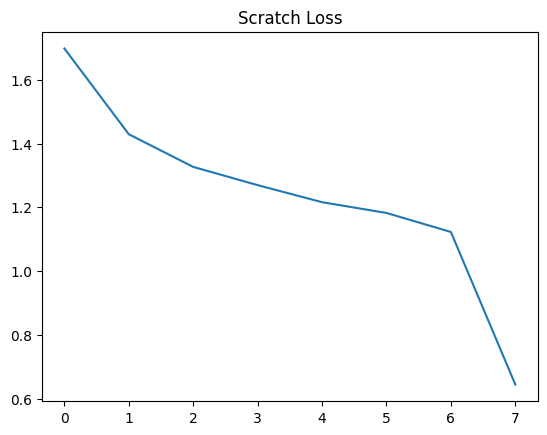

In [13]:
# Train from scratch
model_scratch = UNet(NUM_CLASSES)
model_scratch = train_model(model_scratch, "Scratch", epochs=8)

In [14]:
# =========================================================
# METRICS — per-class IoU + Dice (segmentation)
# =========================================================

def compute_iou(pred, gt):
    intersection = np.logical_and(pred, gt).sum()
    union        = np.logical_or(pred, gt).sum()
    if union == 0:
        return 0
    return intersection / union


def dice_score(pred, gt):
    intersection = (pred * gt).sum()
    return (2 * intersection) / ((pred.sum() + gt.sum()) + 1e-8)


def compute_per_class_seg_metrics(all_preds, all_masks, num_classes):
    """Per-class IoU and Dice — classes 1..num_classes (0=background skipped)"""
    iou_per_class  = []
    dice_per_class = []

    for cls in range(1, num_classes + 1):
        pred_cls = (all_preds == cls)
        mask_cls = (all_masks == cls)

        intersection = np.logical_and(pred_cls, mask_cls).sum()
        union        = np.logical_or(pred_cls,  mask_cls).sum()

        iou  = np.nan if union == 0 else intersection / union

        denom = pred_cls.sum() + mask_cls.sum()
        dice  = np.nan if denom == 0 else (2 * intersection) / denom

        iou_per_class.append(iou)
        dice_per_class.append(dice)

    return np.array(iou_per_class), np.array(dice_per_class)

In [15]:
# =========================================================
# DETECTION METRICS — mAP, ROC, AUC, F1
# Bounding boxes extracted from predicted masks via connected components.
# IoU-based matching against GT boxes.
# =========================================================

def bbox_iou(b1, b2):
    """Compute IoU between two boxes [x1,y1,x2,y2]"""
    ix1 = max(b1[0], b2[0])
    iy1 = max(b1[1], b2[1])
    ix2 = min(b1[2], b2[2])
    iy2 = min(b1[3], b2[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    a1    = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2    = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0


def extract_pred_boxes(mask, num_classes, min_area=50):
    """Extract predicted bounding boxes + scores from a segmentation mask."""
    boxes, labels, scores = [], [], []
    for cls in range(1, num_classes + 1):
        binary       = (mask == cls).astype(np.uint8)
        labeled, num = ndimage.label(binary)
        for i in range(1, num + 1):
            region = (labeled == i)
            area   = region.sum()
            if area < min_area:
                continue
            ys, xs = np.where(region)
            boxes.append([int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())])
            labels.append(cls)
            scores.append(float(area) / (256 * 256))   # proxy confidence = area fraction
    return boxes, labels, scores


def compute_detection_metrics(all_preds, val_data_subset, num_classes,
                               iou_thresholds=None, img_size=256):
    """
    Compute per-class AP at multiple IoU thresholds (COCO-style mAP@[0.5:0.95]),
    plus macro F1, per-class AUC and ROC curves.
    """
    if iou_thresholds is None:
        iou_thresholds = np.arange(0.5, 1.0, 0.05)

    # Collect all detections and GT for each class
    class_tp   = {c: [] for c in range(1, num_classes + 1)}
    class_fp   = {c: [] for c in range(1, num_classes + 1)}
    class_sc   = {c: [] for c in range(1, num_classes + 1)}
    class_ngt  = {c: 0  for c in range(1, num_classes + 1)}

    # For ROC/AUC: image-level binary presence per class
    gt_presence   = {c: [] for c in range(1, num_classes + 1)}
    pred_presence = {c: [] for c in range(1, num_classes + 1)}

    for pred_mask, sample in zip(all_preds, val_data_subset):

        gt_boxes  = sample["boxes"]
        gt_labels = sample["labels"]

        # Scale GT boxes from original image coords to 256x256
        img = cv2.imread(sample["img_path"])
        if img is None:
            continue
        oh, ow = img.shape[:2]
        sx, sy = img_size / ow, img_size / oh

        gt_boxes_scaled = []
        for b in gt_boxes:
            x1 = int(b[0] * sx); y1 = int(b[1] * sy)
            x2 = int(b[2] * sx); y2 = int(b[3] * sy)
            gt_boxes_scaled.append([x1, y1, x2, y2])

        pred_boxes, pred_labels, pred_scores = extract_pred_boxes(pred_mask, num_classes)

        matched = set()

        for c in range(1, num_classes + 1):
            gt_c    = [b for b, l in zip(gt_boxes_scaled, gt_labels) if l == c]
            pred_c  = [(b, s) for b, l, s in zip(pred_boxes, pred_labels, pred_scores) if l == c]

            class_ngt[c] += len(gt_c)

            # Image-level presence for ROC
            gt_presence[c].append(1 if len(gt_c) > 0 else 0)
            pred_presence[c].append(max([s for _, s in pred_c], default=0.0))

            for (pb, ps) in sorted(pred_c, key=lambda x: -x[1]):
                best_iou, best_j = 0, -1
                for j, gb in enumerate(gt_c):
                    iou = bbox_iou(pb, gb)
                    if iou > best_iou:
                        best_iou, best_j = iou, j

                class_sc[c].append(ps)
                if best_iou >= 0.5 and best_j not in matched:
                    class_tp[c].append(1)
                    class_fp[c].append(0)
                    matched.add(best_j)
                else:
                    class_tp[c].append(0)
                    class_fp[c].append(1)

    # --- Per-class AP at each IoU threshold ---
    ap_per_class_per_iou = {}
    for c in range(1, num_classes + 1):
        aps = []
        sc  = np.array(class_sc[c])
        tp  = np.array(class_tp[c])
        fp  = np.array(class_fp[c])
        ngt = class_ngt[c]

        if len(sc) == 0 or ngt == 0:
            aps.append(0.0)
        else:
            order  = np.argsort(-sc)
            tp_cum = np.cumsum(tp[order])
            fp_cum = np.cumsum(fp[order])
            rec    = tp_cum / (ngt + 1e-8)
            prec   = tp_cum / (tp_cum + fp_cum + 1e-8)
            # 11-point interpolation
            ap = 0
            for t in np.linspace(0, 1, 11):
                p = prec[rec >= t].max() if (rec >= t).any() else 0
                ap += p / 11
            aps.append(ap)
        ap_per_class_per_iou[c] = np.mean(aps)

    mAP = np.mean(list(ap_per_class_per_iou.values()))

    # --- Macro F1, per-class AUC, ROC ---
    auc_per_class = {}
    roc_per_class = {}
    for c in range(1, num_classes + 1):
        gt_arr   = np.array(gt_presence[c])
        pred_arr = np.array(pred_presence[c])
        if gt_arr.sum() == 0 or (1 - gt_arr).sum() == 0:
            auc_per_class[c] = float('nan')
            roc_per_class[c] = None
        else:
            fpr, tpr, _ = roc_curve(gt_arr, pred_arr)
            auc_per_class[c] = auc(fpr, tpr)
            roc_per_class[c] = (fpr, tpr)

    # Image-level binary F1 per class, then macro average
    f1_per_class = {}
    for c in range(1, num_classes + 1):
        gt_arr   = np.array(gt_presence[c])
        pred_bin = (np.array(pred_presence[c]) > 0).astype(int)
        if gt_arr.sum() == 0:
            f1_per_class[c] = float('nan')
        else:
            f1_per_class[c] = f1_score(gt_arr, pred_bin, zero_division=0)

    macro_f1 = np.nanmean(list(f1_per_class.values()))

    return mAP, ap_per_class_per_iou, auc_per_class, roc_per_class, f1_per_class, macro_f1

In [16]:
results = []

def evaluate(model, name):

    model.eval()

    ious  = []
    dices = []
    all_preds_list = []
    all_masks_list = []

    for imgs, masks in tqdm(val_loader):

        imgs = imgs.to(device)

        with torch.no_grad():
            preds = model(imgs)

        preds = torch.argmax(preds, dim=1).cpu().numpy()
        masks = masks.numpy()

        for p, g in zip(preds, masks):
            ious.append(compute_iou(p, g))
            dices.append(dice_score(p, g))

        all_preds_list.append(preds)
        all_masks_list.append(masks)

    all_preds = np.concatenate(all_preds_list)
    all_masks = np.concatenate(all_masks_list)

    mean_iou  = np.mean(ious)
    mean_dice = np.mean(dices)

    # Per-class segmentation metrics
    iou_pc, dice_pc = compute_per_class_seg_metrics(all_preds, all_masks, NUM_CLASSES)
    miou_pc   = np.nanmean(iou_pc)
    mdice_pc  = np.nanmean(dice_pc)

    # Detection metrics on val subset (first len(all_preds) samples)
    val_subset = val_data[:len(all_preds)]
    mAP, ap_pc, auc_pc, roc_pc, f1_pc, macro_f1 = compute_detection_metrics(
        all_preds, val_subset, NUM_CLASSES
    )

    results.append([name, mean_iou, mean_dice, training_times.get(name, 0)])

    print(f"\n{'='*55}")
    print(f"Model: {name}")
    print(f"{'='*55}")
    print(f"\n--- Segmentation ---")
    print(f"Overall IoU (binary): {mean_iou:.4f}")
    print(f"Overall Dice:         {mean_dice:.4f}")
    print(f"mIoU (per-class):     {miou_pc:.4f}")
    print(f"mDice (per-class):    {mdice_pc:.4f}")
    print(f"\nPer-class Segmentation:")
    for i, cname in enumerate(CLASS_NAMES[1:]):
        iou_str  = f"{iou_pc[i]:.4f}"  if not np.isnan(iou_pc[i])  else "nan"
        dice_str = f"{dice_pc[i]:.4f}" if not np.isnan(dice_pc[i]) else "nan"
        print(f"  {cname:<20} IoU: {iou_str:>8}   Dice: {dice_str:>8}")

    print(f"\n--- Detection ---")
    print(f"mAP@0.5:       {mAP:.4f}")
    print(f"Macro F1:      {macro_f1:.4f}")
    print(f"\nPer-class Detection:")
    for c in range(1, NUM_CLASSES + 1):
        auc_str = f"{auc_pc[c]:.4f}" if not np.isnan(auc_pc[c]) else "nan"
        f1_str  = f"{f1_pc[c]:.4f}"  if not np.isnan(f1_pc[c])  else "nan"
        print(f"  {CLASS_NAMES[c]:<20} AP: {ap_pc[c]:.4f}   AUC: {auc_str}   F1: {f1_str}")

    # ROC curves
    fig, ax = plt.subplots(figsize=(8, 6))
    for c in range(1, NUM_CLASSES + 1):
        if roc_pc[c] is not None:
            fpr, tpr = roc_pc[c]
            ax.plot(fpr, tpr, label=f"{CLASS_NAMES[c]} (AUC={auc_pc[c]:.2f})")
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC Curves — {name}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/{name}_roc.png")
    plt.close()
    print(f"ROC curve saved: /kaggle/working/{name}_roc.png")


evaluate(model_scratch, "Scratch")

100%|██████████| 625/625 [01:53<00:00,  5.52it/s]



Model: Scratch

--- Segmentation ---
Overall IoU (binary): 0.3414
Overall Dice:         0.6210
mIoU (per-class):     0.3068
mDice (per-class):    0.4695

Per-class Segmentation:
  short sleeve top     IoU:   0.3003   Dice:   0.4619
  trousers             IoU:   0.3134   Dice:   0.4772
  shorts               IoU:      nan   Dice:      nan
  long sleeve top      IoU:      nan   Dice:      nan
  skirt                IoU:      nan   Dice:      nan

--- Detection ---
mAP@0.5:       0.0791
Macro F1:      0.2478

Per-class Detection:
  short sleeve top     AP: 0.2336   AUC: 0.4993   F1: 0.6679
  trousers             AP: 0.1621   AUC: 0.7628   F1: 0.5709
  shorts               AP: 0.0000   AUC: 0.5000   F1: 0.0000
  long sleeve top      AP: 0.0000   AUC: 0.5000   F1: 0.0000
  skirt                AP: 0.0000   AUC: 0.5000   F1: 0.0000
ROC curve saved: /kaggle/working/Scratch_roc.png


In [17]:
print("\nMODEL COMPARISON\n")
print("Model | IoU | Dice | Training Time")
for r in results:
    print(r)


MODEL COMPARISON

Model | IoU | Dice | Training Time
['Scratch', np.float64(0.3414303365878355), np.float64(0.6210043460520192), 9989.7906062603]


In [18]:
def extract_instances(mask):

    instances = []
    classes   = np.unique(mask)

    for cls in classes:

        if cls == 0:
            continue

        binary       = (mask == cls).astype(np.uint8)
        labeled, num = ndimage.label(binary)

        for i in range(1, num + 1):

            region = (labeled == i)
            ys, xs = np.where(region)

            if len(xs) == 0:
                continue

            x1, x2 = xs.min(), xs.max()
            y1, y2 = ys.min(), ys.max()

            instances.append({
                "bbox":  [x1, y1, x2, y2],
                "class": int(cls)
            })

    return instances

[{'bbox': [np.int64(93), np.int64(50), np.int64(168), np.int64(109)], 'class': 1}, {'bbox': [np.int64(94), np.int64(101), np.int64(161), np.int64(219)], 'class': 2}]


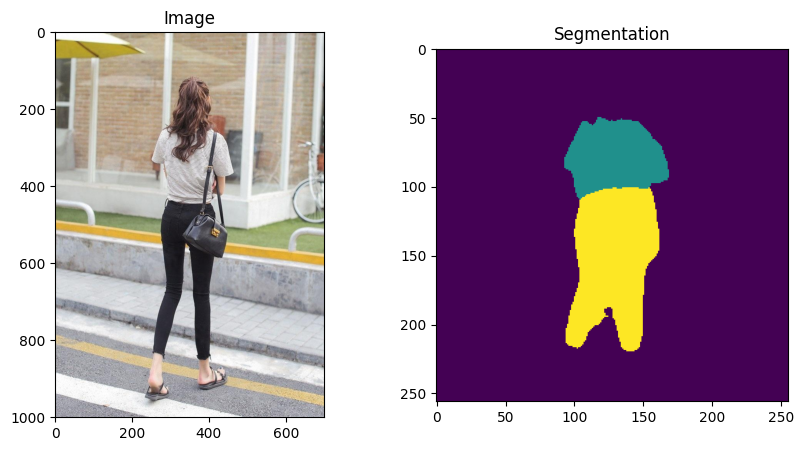

In [19]:
sample = train_data[0]

img = cv2.imread(sample["img_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_input = torch.tensor(cv2.resize(img, (256, 256))).permute(2, 0, 1).float() / 255
img_input = img_input.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model_scratch(img_input)

mask = torch.argmax(pred, dim=1).cpu().numpy()[0]

instances = extract_instances(mask)
print(instances)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img);  plt.title("Image")
plt.subplot(1, 2, 2); plt.imshow(mask); plt.title("Segmentation")
plt.savefig("/kaggle/working/sample_prediction.png")

In [20]:
import os
print(os.listdir("/kaggle/working"))

['Scratch.pth', 'Scratch_roc.png', 'sample_prediction.png', 'Scratch_loss.png', '__notebook__.ipynb', 'label_map.json']
